# Student Performance — Exploratory Data Analysis

## Purpose

This notebook explores the cleaned Student Performance Factors dataset
to investigate how study habits, attendance, and other factors relate
to exam scores.

The analysis will include:
- Reviewing distinct values and the `Unknown` category used during cleaning.
- Exploring summary statistics and distributions.
- Creating visualisations to address the project’s research questions.
- Recording findings and limitations.

The cleaned dataset is loaded from:
`data/processed/StudentPerformanceFactors_cleaned.csv`

Relationships observed in this analysis do not prove cause and effect.


## Research Aim and Questions

### Aim

Explore factors associated with student exam performance to identify
potential support needs and inform school support planning.

### Research Questions

1. Is attendance associated with exam scores after accounting for
   previous scores and study hours?

2. Does the relationship between tutoring sessions and exam scores
   differ according to students' previous scores?

3. Is access to resources associated with exam scores after accounting
   for family income and previous scores?

### Scope

The analysis will explore associations, not establish cause and effect.
Findings will be interpreted in light of the dataset's unverified
collection method and representativeness.

## Hypotheses

### 1. Attendance and Exam Performance

- **H₀ (null):** Attendance is not associated with exam scores after
  accounting for previous scores and study hours.
- **H₁ (alternative):** Attendance is associated with exam scores after
  accounting for previous scores and study hours.

### 2. Tutoring and Previous Performance

- **H₀ (null):** The relationship between tutoring sessions and exam
  scores does not vary with previous scores.
- **H₁ (alternative):** The relationship between tutoring sessions and
  exam scores varies with previous scores.

This will be examined using an interaction between tutoring sessions
and previous scores, including both variables in the model.

### 3. Access to Resources and Exam Performance

- **H₀ (null):** Adjusted mean exam scores are equal across Low, Medium
  and High resource-access groups, accounting for family income and
  previous scores.
- **H₁ (alternative):** At least one resource-access group has a different
  adjusted mean exam score, accounting for these factors.

### Testing Approach

Use regression models to examine these relationships while accounting
for the specified factors. Check model assumptions before interpreting
results, and report effect sizes and confidence intervals alongside
p-values.

Use a significance level of 0.05, with a Holm correction across the
three primary hypothesis tests to account for multiple testing.
Results describe associations and do not establish causation.

## Import Libraries

Import the libraries needed to load, explore and visualise the cleaned dataset.

In [2]:
# Data handling and numerical operations
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# File paths
from pathlib import Path

## Check the Working Directory

Check the notebook's current working directory before setting the path
to the cleaned dataset.

In [3]:
# Display the current working directory
Path.cwd()

WindowsPath('c:/projects/student-performance-analysis/jupyter_notebooks')

## Load the Cleaned Dataset

Load the cleaned CSV from the project's `data/processed` folder
and preview the first five rows.

In [4]:
# Locate the cleaned dataset from the notebook's working directory
data_path = Path("..") / "data" / "processed" / "StudentPerformanceFactors_cleaned.csv"

# Load the cleaned dataset
df = pd.read_csv(data_path)

# Preview the first five rows
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## Review Distinct Values

Count the number of different values in each column.
The `Unknown` label is included as a distinct value wherever it appears.

In [5]:
# Count distinct values and sort from largest to smallest
df.nunique().sort_values(ascending=False).to_frame(name="Distinct Values")

,Distinct Values
Previous_Scores,51
Exam_Score,45
Attendance,41
Hours_Studied,41
Tutoring_Sessions,9
Sleep_Hours,7
Physical_Activity,7
Teacher_Quality,4
Parental_Education_Level,4
Distance_from_Home,4


### Findings

- Previous_Scores has the most distinct values (51), followed by
  Exam_Score (45).
- Attendance and Hours_Studied each have 41 distinct values.
- Teacher_Quality, Parental_Education_Level and Distance_from_Home
  each have four categories, including `Unknown` added during cleaning.
- Five columns have two categories each: Extracurricular_Activities,
  Internet_Access, School_Type, Learning_Disabilities and Gender.
- `Unknown` represents missing information, so it should not be
  interpreted as a measured level when comparing groups.

## Review Unknown Categories

Missing entries were labelled `Unknown` during cleaning.
Count these entries and calculate their percentage of the dataset
to inform later comparisons.

In [6]:
# Select the columns where missing values were labelled Unknown
# Based on reference materials from GeeksforGeeks and the pandas documentation
# (pandas.pydata.org), adapted for this project with ChatGPT assistance.
unknown_columns = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

# Count Unknown entries in each column
unknown_counts = df[unknown_columns].eq("Unknown").sum()

# Display counts and percentages, largest first
unknown_summary = pd.DataFrame({
    "Unknown Count": unknown_counts,
    "Percentage (%)": (unknown_counts / len(df) * 100).round(2)
})

unknown_summary.sort_values("Unknown Count", ascending=False)

,Unknown Count,Percentage (%)
Parental_Education_Level,90,1.36
Teacher_Quality,78,1.18
Distance_from_Home,67,1.01


### Findings

- Parental_Education_Level has 90 Unknown entries (1.36%).
- Teacher_Quality has 78 Unknown entries (1.18%).
- Distance_from_Home has 67 Unknown entries (1.01%).
- Each column has fewer than 1.5% Unknown entries. These may overlap
  across the same students, so the counts cannot be added to calculate
  the number of affected students.
- All rows remain in the cleaned dataset. Unknown entries will be
  identified separately in categorical summaries and will not be
  treated as an ordered level such as Low, Medium or High.

## Descriptive Statistics

Summarise the numerical columns using counts, means, standard deviations,
minimums, quartiles and maximums. These statistics help describe typical
values and how widely the data varies.

In [7]:
# Summarise numerical columns, with one row per variable
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.98,5.99,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.98,11.55,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.03,1.47,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.07,14.40,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.49,1.23,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.97,1.03,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.24,3.89,55.0,65.0,67.0,69.0,101.0


### Findings

- All seven numerical columns contain 6,607 values, with no missing entries.
- Hours_Studied has a mean of 19.98 and a median of 20.
  The middle 50% of values lie between 16 and 24.
- Attendance averages 79.98%, with values ranging from 60% to 100%.
- Sleep_Hours has a mean of 7.03 and a median of 7.
- Previous_Scores averages 75.07, while Exam_Score averages 67.24.
  This difference alone does not establish a decline in performance,
  as the assessments may differ.
- Tutoring_Sessions has a median of 1 and ranges from 0 to 8.
- Physical_Activity has a mean of 2.97 and a median of 3.
- Exam_Score has a median of 67, with the middle 50% between 65 and 69.
  Its standard deviation is 3.89.
- The maximum Exam_Score of 101 remains flagged as an unresolved
  data quality issue and has been retained.

## Distribution of Exam Scores

A histogram shows how frequently different exam scores occur.
This helps us examine the distribution's centre, spread and shape.

The flagged score of 101 is included because it was retained during cleaning.

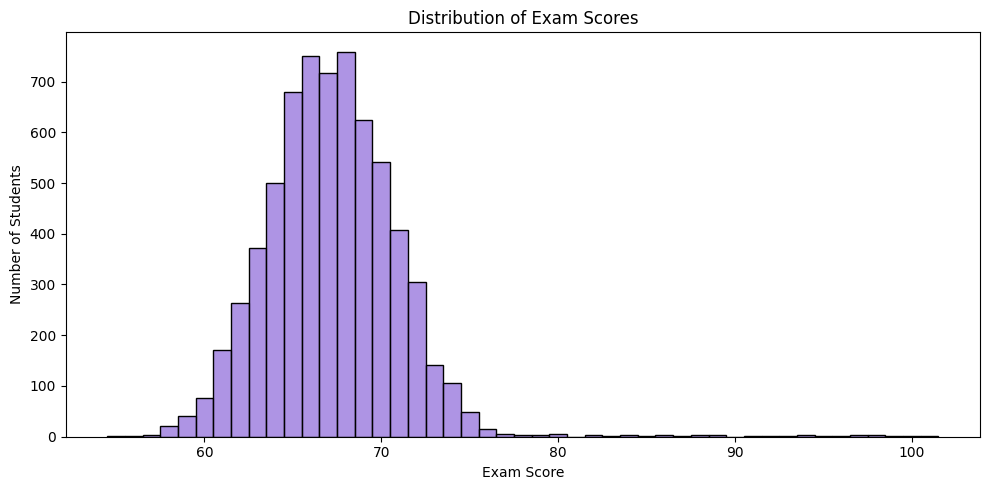

In [8]:
# Created with ChatGPT assistance for this project's analysis.

# Create a histogram with one bin for each integer score
%matplotlib inline
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="Exam_Score",
    discrete=True,
    color="mediumpurple"
)

# Add a descriptive title and axis labels
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.tight_layout()

# Save the chart in the project's visualisations folder
plt.savefig("../visualisations/exam_score_distribution.png", dpi=300)
plt.show()

### Findings

- Exam scores are concentrated around the mid-to-high 60s.
- Most scores fall approximately between 60 and 75.
- The central cluster is roughly bell-shaped, but a small number of
  high scores create a long right-hand tail.
- The overall distribution is therefore right-skewed.
- The flagged score of 101 remains included, pending confirmation
  of the permitted scoring range.

## Distribution of Study Hours

This histogram shows how study hours are distributed across students,
including the most common values and the spread of study time.

In [9]:
%pip install "nbformat>=4.2.0"

Note: you may need to restart the kernel to use updated packages.


In [10]:
# References: Plotly documentation — Box Plots and Interactive HTML Export
# https://plotly.com/python/box-plots/
# https://plotly.com/python/interactive-html-export/
# Code adjusted for this project's dataset and styling with ChatGPT assistance.

# Create an interactive box plot of study hours

fig = px.box(
    df,
    x="Hours_Studied",
    points="outliers",
    title="Distribution of Study Hours",
    labels={"Hours_Studied": "Hours Studied"},
    color_discrete_sequence=["#4682B4"]
)

# Adjust the chart's appearance
fig.update_layout(
    template="plotly_white",
    width=900,
    height=400
)

# Save an interactive copy and display it in the notebook
fig.write_html("../visualisations/study_hours_boxplot.html")
fig.show()

### Findings

- The median study time is 20 hours.
- The middle 50% of students have study times between 16 and 24 hours,
  giving an interquartile range (IQR) of 8 hours.
- Using the 1.5 × IQR rule, values below 4 or above 36 hours are
  flagged as potential outliers.
- These values were investigated during cleaning and retained,
  because unusual study times are not necessarily errors.
- This chart describes study time; it does not show its relationship
  with exam scores.

## Attendance and Exam Scores

This scatter plot explores the relationship between attendance and
exam scores. Each point represents a student, although points may
overlap. A fitted straight line summarises the overall linear trend.

This initial chart does not account for previous scores or study hours.
Those factors will be included during hypothesis testing.

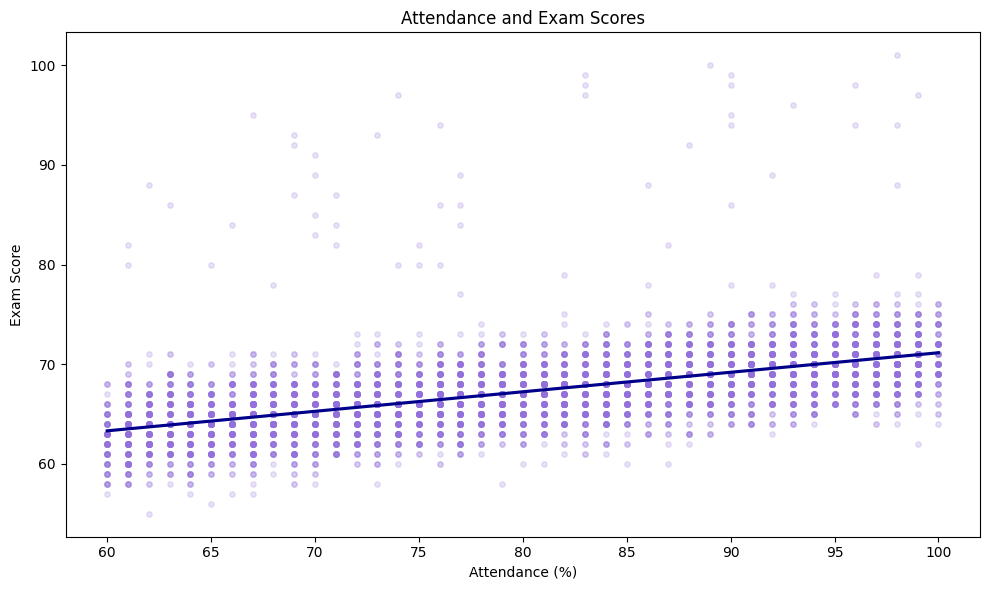

In [11]:
# Created with ChatGPT assistance for this project's analysis.

# Plot student results with a fitted linear trend
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x="Attendance",
    y="Exam_Score",
    ci=None,
    scatter_kws={"alpha": 0.2, "s": 15, "color": "mediumpurple"},
    line_kws={"color": "darkblue"}
)

# Add a title and axis labels
plt.title("Attendance and Exam Scores")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")
plt.tight_layout()

# Save the chart and display it in the notebook
plt.savefig("../visualisations/attendance_vs_exam_score.png", dpi=300)
plt.show()

### Findings

- The upward trend line suggests a positive association between
  attendance and exam scores.
- Scores vary among students with the same attendance, so attendance
  alone does not explain performance.
- Some unusually high scores appear across different attendance levels.
- This chart does not account for previous scores or study hours.
  Further analysis is needed to address the first research question.
- The observed association does not establish causation.